# Natural Language Processing Project
## RAG_Against the Machine
Christian Ferrareis\
Niccolo Giallongo\
Manuel del Carmen Fernández\
Miguel Planas 

In [3]:
import pandas as pd
import random
from datasets import load_dataset
from matplotlib import pyplot as plt
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
import hnswlib
import pyterrier as pt
from tqdm import tqdm
from gensim.models.word2vec import Word2Vec

In [4]:
ds = load_dataset("FreedomIntelligence/RAG-Instruct", split="train")

README.md:   0%|          | 0.00/2.64k [00:00<?, ?B/s]

rag_instruct.json:   0%|          | 0.00/296M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40541 [00:00<?, ? examples/s]

# 1. Preliminary analysis

## Structure of the dataset
- The dataset is structured with three main features: 'question', 'answer', and 'documents'. Specifically, each question is associated with exactly 10 context documents.
- This structure strongly suggests that the dataset was collected for a Retrieval Augmented Generation (RAG) task. In such tasks, a model retrieves relevant documents and then uses that information to generate an answer to a given question.
- The documents are sourced from a diverse range of domains, including Wikipedia, books, and news articles, ensuring broad topic coverage.
- The full dataset contains 40,541 such question-answer-document instances.

In [5]:
print(f"Number of samples for training set: {ds.num_rows}")
print(f"Features of the dataset: {ds.column_names}")

Number of samples for training set: 40541
Features of the dataset: ['question', 'answer', 'documents']


In [6]:
ds[0]

{'question': "Describe the cultural impact and legacy of the 1967 Disney film 'The Jungle Book' on animation and popular culture.",
 'answer': "The 1967 Disney film 'The Jungle Book' has had a profound impact on animation and popular culture. It was the last animated film produced by Walt Disney himself, marking an end to an era of his personal touch in Disney films. The movie is notable for using familiar celebrity voices to shape character personalities, such as Phil Harris improvising lines for Baloo, a rare practice in Disney movies of the time which later became a more common trend in animation. This practice helped create more relatable and memorable characters, contributing to the film's lasting popularity. Culturally, 'The Jungle Book' introduced audiences to a blend of humor, adventure, and catchy music, which have been influential in defining the modern animated musical genre. The film's success led to the expansion of 'The Jungle Book' into a media franchise, which includes 

In [7]:
q_word_counts = [len(s['question'].split()) for s in ds]
a_word_counts = [len(s['answer'].split()) for s in ds]
d_counts = [len(s) for s in ds['documents']]
words_d_counts = [len(d.split()) for s in ds for d in s['documents']]

## Length and distribution
- The average word count for questions is approximately 21 words. The distribution of question word counts is shown in the histogram.
- The average word count for answers is about 91 words.
- Each of the 10 context documents provided for a question has a fixed length of 100 words.

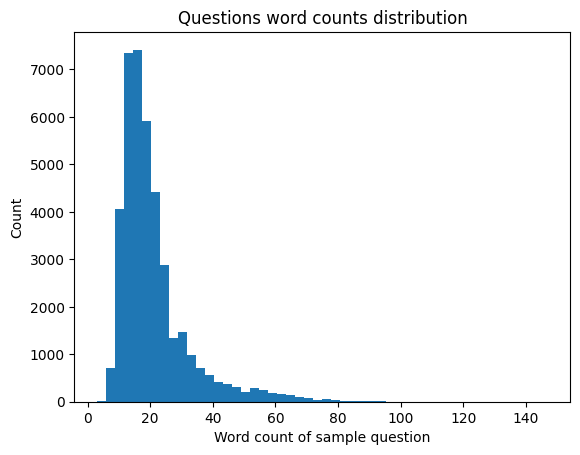

Avarage word count for questions: 20.98887545941146


In [8]:
plt.hist(q_word_counts, bins=50)
plt.xlabel('Word count of sample question')
plt.ylabel('Count')
plt.title('Questions word counts distribution')
plt.show()

print(f"Avarage word count for questions: {np.mean(q_word_counts)}")

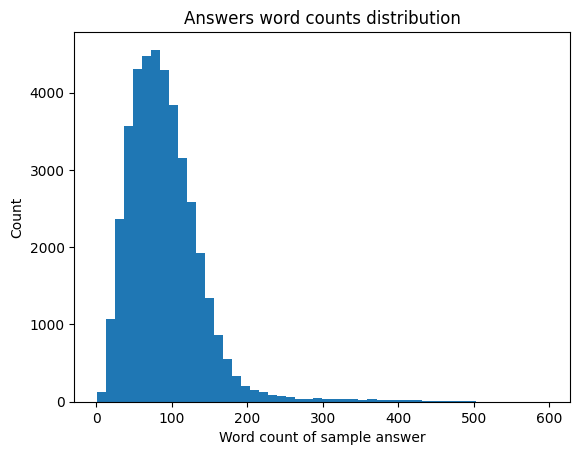

Avarage word count for answers: 91.17352803334896


In [9]:
plt.hist(a_word_counts, bins=50)
plt.xlabel('Word count of sample answer')
plt.ylabel('Count')
plt.title('Answers word counts distribution')
plt.show()

print(f"Avarage word count for answers: {np.mean(a_word_counts)}")

*Each QA has 10 documents, each having exactly 100 words:*

In [10]:
print(f"Document counts: {np.unique(d_counts)[0]}")
print(f"Word counts: {np.unique(words_d_counts)[0]}")

Document counts: 10
Word counts: 100


## Vocabulary Size
The first step was to apply filtering: lowercase, removing non-alphanumeric characters and stopwords, and words with length > 1.
The total unique vocabulary size across all filtered questions, answers, and documents in the analyzed portion of the dataset is 373,945.
### Filtered vocabulary
- The filtered vocabulary size for questions is 35,411.
- The filtered vocabulary size for answers is 69,259.
- The filtered vocabulary size for all documents combined is 373,006.
### Average vocabulary
- Average Vocabulary of a Document: The average number of unique filtered words per individual document is approximately 57.77.
- Average Vocabulary of a Question: The average number of unique filtered words per question is approximately 12.16.
- Average Vocabulary of an Answer: The average number of unique filtered words per answer is approximately 55.81.

In [11]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def filter_words(s):
    s = s.lower()
    s = re.sub(r'\W+', ' ', s)
    words = s.split()
    words = [word for word in words 
             if word.isalpha() and word not in stop_words and len(word) > 1
    ]
    return words

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
q_vocabulary = nltk.FreqDist()
a_vocabulary = nltk.FreqDist()
docs_vocabulary = nltk.FreqDist()

for s in ds:
    words_q = filter_words(s['question'])
    words_a = filter_words(s['answer'])
    for d in s['documents']:
        words_doc = filter_words(d)
        docs_vocabulary.update(words_doc)
        
    q_vocabulary.update(words_q)
    a_vocabulary.update(words_a)

In [13]:
print(f"Questions vocabulary size: {len(q_vocabulary)}")
print(f"Answers vocabulary size: {len(a_vocabulary)}")
print(f"Documents vocabulary size: {len(docs_vocabulary)}")

Questions vocabulary size: 39359
Answers vocabulary size: 76428
Documents vocabulary size: 420020


In [14]:
vocab_size = len(set(q_vocabulary) | set(a_vocabulary) | set(docs_vocabulary))
print(f"Total vocabulary size: {vocab_size}")

Total vocabulary size: 421164


In [15]:
print("Most common words in questions:")
print(*q_vocabulary.most_common(10), sep='\n')

Most common words in questions:
('following', 4270)
('explain', 3969)
('question', 3074)
('answer', 2862)
('correct', 2517)
('describe', 2416)
('options', 2397)
('statement', 2340)
('discuss', 2182)
('true', 2109)


In [16]:
print("Most common words in answers:")
print(*a_vocabulary.most_common(10), sep='\n')

Most common words in answers:
('like', 13928)
('text', 7131)
('also', 6317)
('significant', 6171)
('used', 5901)
('data', 5522)
('due', 5390)
('additionally', 5161)
('use', 4877)
('one', 4865)


In [17]:
voc_size_q = [len(filter_words(s['question'])) for s in ds]
voc_size_a = [len(filter_words(s['answer'])) for s in ds]
voc_size_doc = [len(filter_words(d)) for s in ds for d in s['documents']]

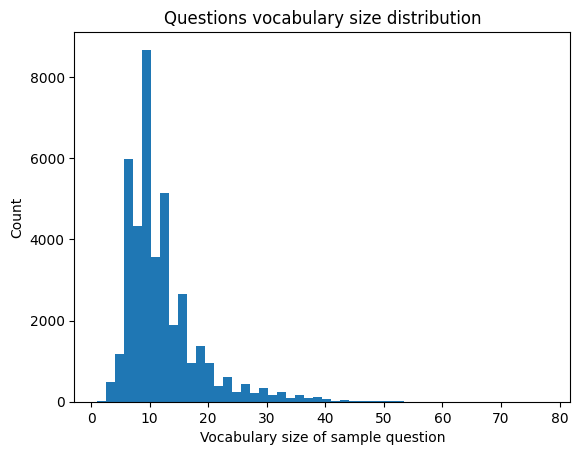

Avarage vocabulary size of questions: 12.158111541402532


In [18]:
plt.hist(voc_size_q, bins=50)
plt.xlabel('Vocabulary size of sample question')
plt.ylabel('Count')
plt.title('Questions vocabulary size distribution')
plt.show()

print(f"Avarage vocabulary size of questions: {np.mean(voc_size_q)}")

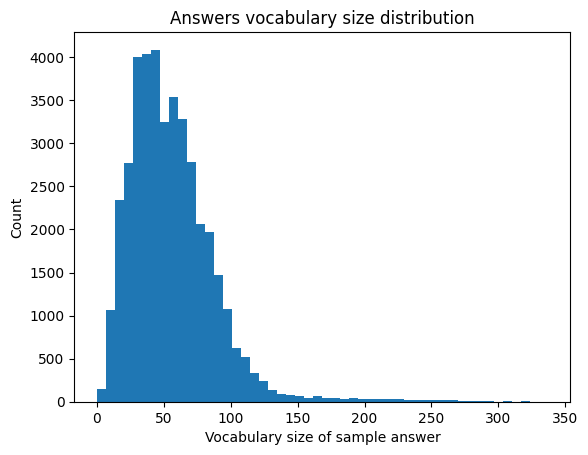

Avarage vocabulary size of answers: 55.8928985471498


In [19]:
plt.hist(voc_size_a, bins=50)
plt.xlabel('Vocabulary size of sample answer')
plt.ylabel('Count')
plt.title('Answers vocabulary size distribution')
plt.show()

print(f"Avarage vocabulary size of answers: {np.mean(voc_size_a)}")

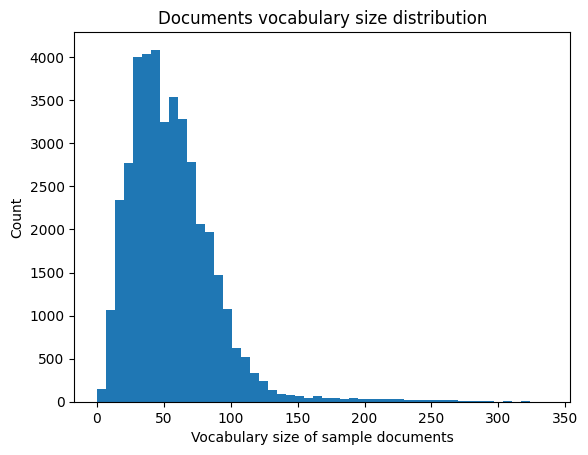

Avarage vocabulary size of documents: 57.76578032115636


In [20]:
plt.hist(voc_size_a, bins=50)
plt.xlabel('Vocabulary size of sample documents')
plt.ylabel('Count')
plt.title('Documents vocabulary size distribution')
plt.show()

print(f"Avarage vocabulary size of documents: {np.mean(voc_size_doc)}")

# Clustering
Clustering is used in this notebook to group similar questions together. The aim is to identify potential "topics" or categories of questions present in the dataset. This can be beneficial for understanding the dataset's diversity, identifying common themes, and potentially aiding in downstream tasks like question routing or building specialized retrieval models for certain topics.

In [21]:
questions = [q for q in ds['question']]

q_vectorizer = TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')

q_vectorizer.fit(questions)

vector_q = q_vectorizer.transform(questions)

k=50


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=60


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=80


...

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=150


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=200


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


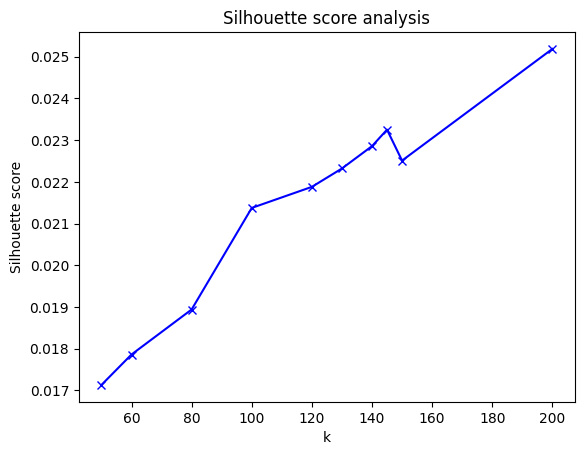

In [22]:

silhouette_scores = []
ks = [50, 60, 80, 100, 120, 130, 140, 145, 150, 200]

for k in ks:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(vector_q)
    score = silhouette_score(vector_q, labels)
    silhouette_scores.append(score)

plt.plot(ks, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score analysis')
plt.show()


*k=150 seems to be a reasonable number of clusters to divide the questions (possible topics)*

In [24]:
kmeans = KMeans(n_clusters=150, random_state=42)
labels = kmeans.fit_predict(vector_q) 

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


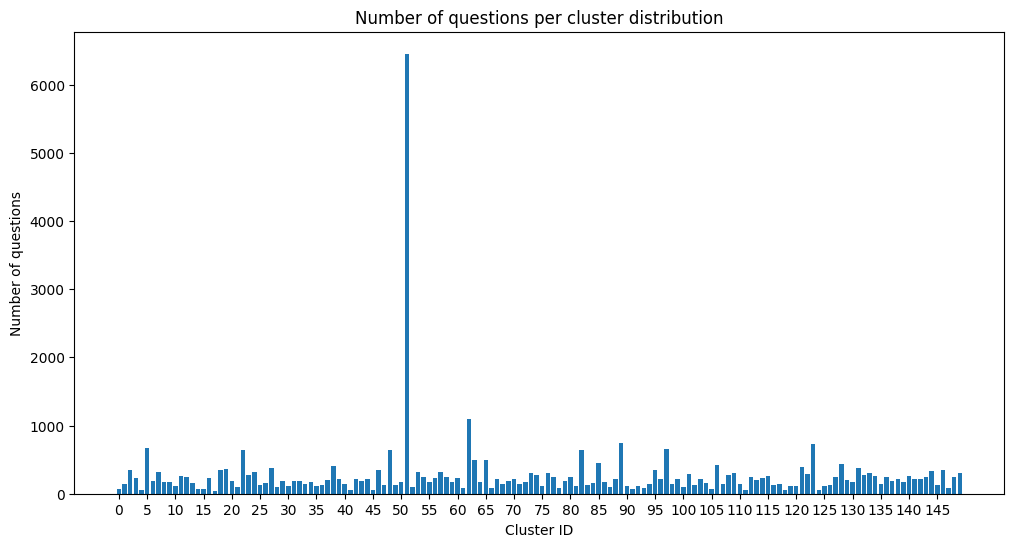

In [25]:
unique_labels, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(12,6))
plt.bar(unique_labels, counts, width=0.8)
plt.xlabel('Cluster ID')
plt.ylabel('Number of questions')
plt.title('Number of questions per cluster distribution')
plt.xticks(unique_labels[::5])#, rotation=90)
plt.show()

In [26]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(3)
reduced_data = svd.fit_transform(vector_q)

[x,y,z] = np.transpose(reduced_data)
[x,y,z]

[array([0.02398905, 0.03185796, 0.04079161, ..., 0.02119775, 0.01946513,
        0.14025388]),
 array([ 0.03425456,  0.06282705,  0.08705067, ...,  0.02527034,
         0.02544863, -0.06185922]),
 array([-0.04250092, -0.04348767, -0.05361073, ..., -0.03961858,
         0.00828664,  0.00599397])]

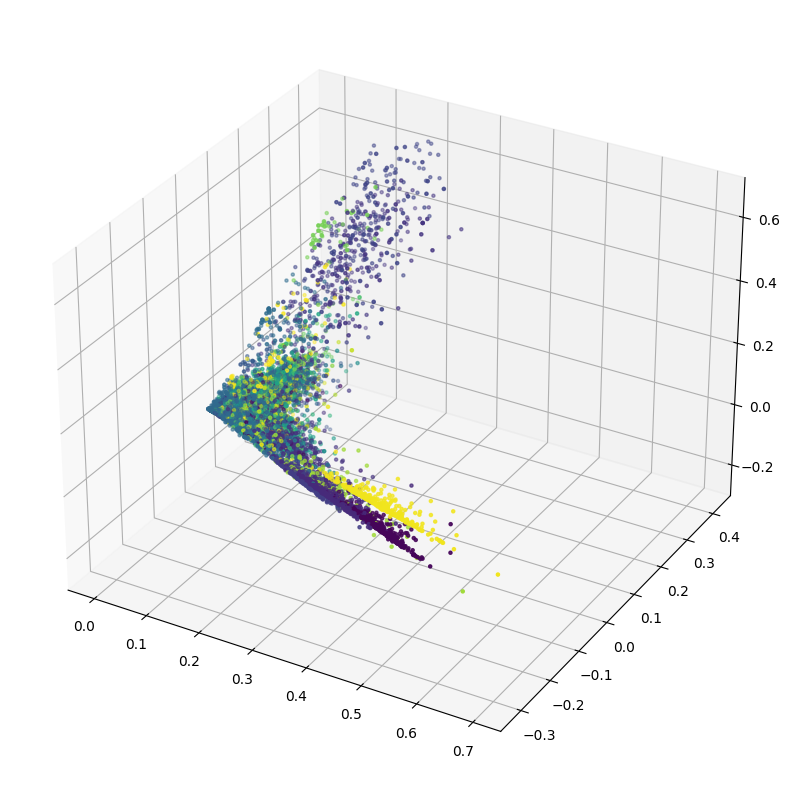

In [27]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=kmeans.labels_, marker='.');

In [28]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



def basic_retrieval(query, data, top_k=5):
    """
    Basic retrieval using TF-IDF.

    """

    # 1. Simple Preprocessing
    # You can add more cleaning if necessary (using the clean_text function from the code)
    documents = ["".join(doc) for s in data['documents'] for doc in s]
    questions = [s['question'] for s in data]  # Ensure that 'data' is iterable in the correct way

    # Combine documents and questions for vectorization
    corpus = documents + [query]

    # 2. TF-IDF Vectorization
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(corpus)

    # Separate the matrix
    document_vectors = tfidf_matrix[:-1]  # Vectors of the documents
    query_vector = tfidf_matrix[-1]       # Vector of the query

    # 3. Calculate Similarity
    similarity_scores = cosine_similarity(query_vector, document_vectors).flatten()

    # 4. Get the Top-k Most Relevant Documents
    top_indices = similarity_scores.argsort()[-top_k:][::-1]
    retrieved_documents = [documents[i] for i in top_indices]

    return retrieved_documents


# Example Usage
query = "Given the context of a user asking how to bake a cake, what are the steps involved?"  # An example question
retrieved_docs = basic_retrieval(query, ds, top_k=3) # Use your 'ds' dataset

print("Question:", query)
print("\nRetrieved Documents:")
for i, doc in enumerate(retrieved_docs):
    print(f"{i+1}. {doc}\n")

Question: Given the context of a user asking how to bake a cake, what are the steps involved?

Retrieved Documents:
1. to have the perfect sponge which holds its form (perfect symmetry), distinguish flavors, and a smooth exterior. For the showstopper, the bakers were asked to bake a chocolate tiered celebration cake with elaborate, multi-layer design. For the signature bake, the bakers were asked to bake a savory Quiche in 2 hours. For the technical challenge, the bakers were asked to bake a Tarte au Citron using Mary's recipe in 1 1/2 hours. For the showstopper, the bakers were asked to bake 24 miniature sweet tarts. For their signature bake, the bakers were asked to bake a free formed flavored loaf

2. one filled. They were given two hours the first day, allowed the dough to rise overnight in the fridge, and then three hours the next day to finish the bake. Episode five aired on June 26, 2013. The theme of the episode was sweet baked goods. For the signature bake, the bakers must mak

# Indexing
Indexing documents is crucial for efficient information retrieval. Instead of searching through every document linearly (which would be very slow for large datasets), an index allows for quick lookup of documents containing specific keywords.

#### Question

In [29]:
if not pt.started():
  pt.init()

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


/tmp/ipykernel_35/4006547969.py:1: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...
Done


Java started and loaded: pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_35/4006547969.py:2: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


In [30]:
q_indexer = pt.DFIndexer("./index_questions", overwrite=True)

q_df = pd.DataFrame({
    "docno": [str(i) for i in range(len(ds["question"]))],
    "text": ds["question"]
})

q_index_ref = q_indexer.index(q_df["text"], q_df["docno"])

q_index = pt.IndexFactory.of(q_index_ref)

/tmp/ipykernel_35/3227464377.py:1: DeprecationWarning: Call to deprecated class DFIndexer. (use pt.terrier.IterDictIndexer().index(dataframe.to_dict(orient='records')) instead) -- Deprecated since version 0.11.0.
  q_indexer = pt.DFIndexer("./index_questions", overwrite=True)


In [31]:
query = "author odyssey"

q_tf_idf = pt.BatchRetrieve(q_index, wmodel="TF_IDF", num_results=10)
q_bm25 = pt.BatchRetrieve(q_index, wmodel="BM25", num_results=10)

/tmp/ipykernel_35/1531928263.py:3: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  q_tf_idf = pt.BatchRetrieve(q_index, wmodel="TF_IDF", num_results=10)
/tmp/ipykernel_35/1531928263.py:4: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  q_bm25 = pt.BatchRetrieve(q_index, wmodel="BM25", num_results=10)


In [32]:
q_tf_idf_df = q_tf_idf.search(query)
q_tf_idf_df

,qid,docid,docno,rank,score,query
0,1,26118,26118,0,12.243719,author odyssey
1,1,10851,10851,1,7.051885,author odyssey
2,1,39133,39133,2,6.599100,author odyssey
3,1,20641,20641,3,6.393833,author odyssey
4,1,38421,38421,4,6.393833,author odyssey
5,1,22033,22033,5,5.681907,author odyssey
6,1,398,398,6,5.174302,author odyssey
7,1,5046,5046,7,5.174302,author odyssey
8,1,39032,39032,8,5.174302,author odyssey
9,1,21715,21715,9,5.091159,author odyssey


In [33]:
q_bm25_df = q_bm25.search(query)
q_bm25_df

,qid,docid,docno,rank,score,query
0,1,26118,26118,0,22.269566,author odyssey
1,1,10851,10851,1,12.791219,author odyssey
2,1,39133,39133,2,11.969923,author odyssey
3,1,20641,20641,3,11.597595,author odyssey
4,1,38421,38421,4,11.597595,author odyssey
5,1,22033,22033,5,10.385365,author odyssey
6,1,398,398,6,9.457567,author odyssey
7,1,5046,5046,7,9.457567,author odyssey
8,1,39032,39032,8,9.457567,author odyssey
9,1,21715,21715,9,9.305598,author odyssey


In [34]:
q = ds['question'][q_tf_idf_df.iloc[0].docid]
print(f"Best matching question for query '{query}': \n{q}")

Best matching question for query 'author odyssey': 
Who might have been the author of the 'Odyssey' according to some theories, including one proposed by Samuel Butler?


# Word embedding (Word2Vec)
Words with similar meanings tend to have similar vector representations in this high-dimensional space. This allows for understanding contextual similarities between words and can be used in various NLP tasks, such as text similarity, recommendation systems, and improving the performance of machine learning models by providing richer input features.

In [35]:
q_tokenized = [filter_words(s) for s in ds['question']]

d_tokenized = [filter_words(d) for s in ds['documents'] for d in s]

In [36]:
tokenized_sentences = q_tokenized + d_tokenized

In [37]:
model = Word2Vec(tokenized_sentences, vector_size=100, min_count=3, window=10, epochs=10)

In [38]:
print(f"The model has learned {len(model.wv)} word vectors")

The model has learned 172423 word vectors


In [39]:
term = "science"

print(f"Word2Vec word embedding for term='{term}': \n{model.wv[term]}")

Word2Vec word embedding for term='science': 
[ 0.87948555  1.689135   -1.5737218  -0.75721586  2.4541438  -1.5069232
  1.0316033  -1.1557802  -1.3449923   2.3988616   0.8313212  -0.36781284
  0.59963167 -1.706176    0.27425757 -3.0998194  -2.5023682  -2.3324847
  0.5105075   1.2082918  -0.25596932 -4.6404696  -5.8006144   4.152355
  0.7081592   2.4612343  -1.2084776  -4.557095   -1.4202745  -2.334118
 -1.4681512  -0.6519089  -0.14450054  1.6894482   3.57285     1.146918
 -1.6332377  -0.58508426 -0.61431587 -3.827455    4.40783    -1.7690914
 -2.9946246  -2.0621111   0.52028733  2.158922   -1.2444896   1.2976632
  3.2197068   0.42839164 -0.28206253  2.2293348   3.1947803  -1.0708472
  1.780596   -3.727859   -1.9616807  -1.9935668  -4.1412444  -0.9975731
 -2.4105961   1.5580386  -1.7515986   0.8509954   2.6402068  -2.1004732
  0.645418    0.8609829   0.8937061  -1.1238216  -3.0478332  -2.9777544
  1.8221967   0.49730667 -0.9987728  -1.4475226  -1.1929879   2.4336336
  4.293643    1.23003

In [40]:
model.wv.most_similar(term)

[('humanities', 0.6730933785438538),
 ('scientific', 0.6251748204231262),
 ('sciences', 0.6205267310142517),
 ('interdisciplinary', 0.6093257069587708),
 ('neuroscience', 0.5809286832809448),
 ('biology', 0.5708016157150269),
 ('physics', 0.5674145221710205),
 ('anthropology', 0.5650683641433716),
 ('cybernetics', 0.5523853898048401),
 ('theorization', 0.5453576445579529)]

In [41]:
sample = random.sample(list(model.wv.key_to_index), 500)

word_vectors = model.wv[sample]

tsne = TSNE(n_components=3, n_iter=2000)
tsne_embedding = tsne.fit_transform(word_vectors)

x, y, z = np.transpose(tsne_embedding)

In [42]:
import plotly.express as px

fig = px.scatter_3d(x=x[:200],y=y[:200],z=z[:200],text=sample[:200])
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

In [43]:
feelings = [
    "happiness",
    "sadness",
    "anger",
    "fear",
    "excitement",
    "disgust",
    "love",
    "anxiety",
    "hope",
    "boredom",
    "gratitude",
    "jealousy"
]

word_vectors = model.wv[feelings+sample]

tsne = TSNE(n_components=3)
tsne_embedding = tsne.fit_transform(word_vectors)

x, y, z = np.transpose(tsne_embedding)

In [44]:
r = (-200,200)
fig = px.scatter_3d(x=x, y=y, z=z, range_x=r, range_y=r, range_z=r, text=feelings + [None] * 500)
fig.update_traces(marker=dict(size=3,line=dict(width=2)),textfont_size=10)
fig.show()

In [45]:
vec = model.wv.get_vector('king') + (model.wv.get_vector('woman') - model.wv.get_vector('man'))